# Urban Flood Risk Prediction Using Machine Learning

**Subject:** Applied Machine Learning & Data Science  
**Project:** Problem-Based Learning (PBL) — Machine Learning Prototype  
**College:** L.D. College of Engineering, Ahmedabad — Gujarat Technological University (GTU)  

---

### Project Overview
Urban flooding is a severe environmental hazard triggered when intense rainfall generates more stormwater runoff than urban drainage infrastructure can convey away. While physical hydraulic simulations (like SWMM or hydrodynamic 2D pipe models) are computationally demanding, a data-driven **Machine Learning (ML)** model can learn relationships directly from data to provide rapid, preliminary decision-support.

In this college project, we design, build, evaluate, and test a complete, beginner-friendly Machine Learning workflow in Python to predict an **Urban Flood Risk Score (0–100)** and classify flood risk into actionable categories.

| Variable | Role | Unit | Valid Range | Physical Interpretation |
|---|---|---|---|---|
| **`Rainfall_Intensity`** | Input Feature ($X_1$) | mm/hr | 0 – 200 | Rate of precipitation during a storm event |
| **`Drainage_Capacity`** | Input Feature ($X_2$) | mm/hr | 0 – 100 | Hydraulic throughput capacity of stormwater drains |
| **`Impervious_Area`** | Input Feature ($X_3$) | % | 0 – 100 | Percentage of catchment paved with impermeable concrete/asphalt |
| **`Flood_Risk`** | Target Variable ($y$) | Score | 0 – 100 | Continuous composite flood vulnerability score |

#### Defined Flood Risk Classifications:
* **Low Flood Risk:** Score $< 40$
* **Medium Flood Risk:** Score from $40$ to $< 60$
* **High Flood Risk:** Score $\ge 60$


## Step 1: Project Introduction

### 1.1 Problem Statement
Urbanization replaces permeable natural soil with impermeable surfaces such as roads, parking lots, and building roofs. During heavy cloudburst or monsoon events, surface runoff accumulates rapidly on city streets. If the drainage network is undersized, poorly maintained, or overwhelmed, severe waterlogging and flash flooding occur, damaging property and disrupting civic life.

### 1.2 Objectives
1. **Synthetic Data Generation:** Create a realistic, reproducible dataset of 2,000 synthetic observations modeling urban rainfall conditions.
2. **Data Understanding & Cleaning:** Perform structured data inspection and verify that all values satisfy physical domain boundaries.
3. **Exploratory Data Analysis (EDA):** Visualize univariate distributions and bivariate relationships with clearly interpreted charts.
4. **Model Training:** Train a single, highly interpretable **Decision Tree Regressor** (`max_depth=6`) to predict continuous flood risk.
5. **Model Evaluation:** Calculate standard regression metrics (**MAE, MSE, RMSE, and $R^2$**) and analyze prediction errors via **Actual vs. Predicted** and **Residual** plots.
6. **Feature Importance:** Extract and visualize the model's learned reliance on the three environmental factors.
7. **Inference Function & Scenario Testing:** Implement an input-validated prediction function and test three specific benchmark scenarios from earlier project milestones.

### 1.3 Machine Learning Approach
Unlike rule-based systems (such as fuzzy logic controllers where IF–THEN rules are hand-crafted by human experts), **Machine Learning** algorithms discover split boundaries and non-linear associations automatically from data. In this project, we employ a **Decision Tree Regressor**, which splits the feature space into hierarchical branches to minimize variance and predict a continuous numeric score.

### 1.4 Limitations of Synthetic Data
> **Important Disclaimer:** This project is an **educational prototype** developed using synthetic (dummy) data generated from documented hydrological principles. It demonstrates the complete Machine Learning engineering methodology. It is **not** a calibrated real-world flood warning system and should not be used for life-critical municipal flood management without empirical rain gauge networks, LiDAR elevation topography, and municipal storm sewer GIS records.


## Step 2: Import Libraries

We import only standard Python libraries needed for the machine learning workflow:
* **NumPy (`np`):** Provides fast multi-dimensional array processing and random number generation.
* **Pandas (`pd`):** Provides DataFrame data structures for loading, cleaning, and transforming tabular data.
* **Matplotlib (`plt`):** Foundational plotting library for creating custom figures, axes, and statistical graphics.
* **Seaborn (`sns`):** Statistical visualization library built on Matplotlib that produces clean, publication-ready color schemes.
* **Scikit-learn (`sklearn`):** Core machine learning toolkit used for train-test splitting (`train_test_split`), model training (`DecisionTreeRegressor`), and performance metrics (`mean_absolute_error`, `mean_squared_error`, `r2_score`).


In [1]:
# Step 2: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities for machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set consistent plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully:")
print(f" - NumPy      : {np.__version__}")
print(f" - Pandas     : {pd.__version__}")
print(f" - Matplotlib : {plt.matplotlib.__version__}")
print(f" - Seaborn    : {sns.__version__}")


Libraries imported successfully:
 - NumPy      : 2.5.2
 - Pandas     : 3.0.5
 - Matplotlib : 3.11.1
 - Seaborn    : 0.13.2


## Step 3: Create the Dummy Dataset

To enable reproducible experimentation without requiring external CSV downloads, we generate a synthetic dataset of **2,000 rows** directly using Python.

We set `np.random.seed(42)` to ensure identical numbers across every run.

### Documented Synthetic Target Formula
The continuous target `Flood_Risk` is calculated using a formula reflecting standard hydrological principles:
$$\text{Base\_Risk} = 25.0 + 0.28 \times \text{Rainfall\_Intensity} - 0.38 \times \text{Drainage\_Capacity} + 0.32 \times \text{Impervious\_Area}$$

$$\text{Flood\_Risk} = \text{clip}(\text{Base\_Risk} + \epsilon, \ 0, \ 100) \quad \text{where} \ \epsilon \sim \mathcal{N}(0, 3^2)$$

### Physical Rationale for the Formula Terms:
1. **$+0.28 \times \text{Rainfall\_Intensity}$:** Precipitation generates stormwater runoff. Across the 0–200 mm/hr range, rainfall contributes up to $56$ risk points.
2. **$-0.38 \times \text{Drainage\_Capacity}$:** Drainage systems remove stormwater from the surface. Across the 0–100 mm/hr range, drainage mitigates up to $38$ risk points.
3. **$+0.32 \times \text{Impervious\_Area}$:** Impermeable surfaces (pavements, rooftops) prevent soil infiltration and accelerate surface runoff. Across the 0–100% range, imperviousness contributes up to $32$ risk points.
4. **$+25.0$ Baseline Intercept:** Establishes a realistic middle-range baseline across diverse conditions.
5. **Random Gaussian Noise ($\epsilon \sim \mathcal{N}(0, 3^2)$):** Adds realistic variance so the data is not perfectly deterministic.
6. **Clipping:** Restricts all target scores strictly within the valid $[0, 100]$ interval.

> **Important Reminder:** This target formula is only a mathematical mechanism to synthesize dummy labels for learning purposes. It is not an expert-validated real-world measurement.


In [2]:
# Step 3: Generate the synthetic dataset
# Set random seed for exact reproducibility
np.random.seed(42)

# Number of synthetic observations
n_samples = 2000

# 1. Generate the three environmental input features uniformly within specified ranges
rainfall = np.random.uniform(0.0, 200.0, n_samples)   # 0 to 200 mm/hr
drainage = np.random.uniform(0.0, 100.0, n_samples)   # 0 to 100 mm/hr
impervious = np.random.uniform(0.0, 100.0, n_samples) # 0 to 100 %

# 2. Compute synthetic flood risk using the documented formula
base_risk = (
    25.0
    + 0.28 * rainfall
    - 0.38 * drainage
    + 0.32 * impervious
)

# 3. Add small random Gaussian noise (mean=0, std=3) to simulate real-world uncertainty
noise = np.random.normal(loc=0.0, scale=3.0, size=n_samples)

# 4. Clip final flood risk scores strictly to [0, 100]
flood_risk = np.clip(base_risk + noise, 0.0, 100.0)

# 5. Assemble into a structured Pandas DataFrame
df = pd.DataFrame({
    'Rainfall_Intensity': np.round(rainfall, 2),
    'Drainage_Capacity': np.round(drainage, 2),
    'Impervious_Area': np.round(impervious, 2),
    'Flood_Risk': np.round(flood_risk, 2)
})

# Display first five rows
print("First 5 rows of the generated dataset:")
display(df.head())

# Display dataset shape and column names
print(f"\nDataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Column Names: {list(df.columns)}")


First 5 rows of the generated dataset:


,Rainfall_Intensity,Drainage_Capacity,Impervious_Area,Flood_Risk
0,74.91,26.17,57.20,51.19
1,190.14,24.70,80.54,96.05
2,146.40,90.63,76.02,56.75
3,119.73,24.95,15.39,56.84
4,31.20,27.19,14.92,25.81



Dataset Dimensions: 2000 rows, 4 columns
Column Names: ['Rainfall_Intensity', 'Drainage_Capacity', 'Impervious_Area', 'Flood_Risk']


## Step 4: Data Understanding

Before analyzing or modeling data, we thoroughly inspect its dimensions, data types, sample values, and summary statistics using:
* `df.head()`: First 5 records
* `df.tail()`: Last 5 records
* `df.shape`: Row and column dimensions
* `df.columns`: List of feature and target names
* `df.info()`: Memory usage, data types, and non-null counts
* `df.describe()`: Descriptive statistics (mean, standard deviation, min, percentiles, max)

### Feature & Target Meanings:
* **`Rainfall_Intensity` (Float, mm/hr):** Quantifies storm severity. Drizzles fall under 20 mm/hr, moderate rains around 50–100 mm/hr, and extreme cloudburst events exceed 120 mm/hr.
* **`Drainage_Capacity` (Float, mm/hr):** Quantifies how much water the municipal storm sewer network can safely discharge per hour. Higher values represent better drainage infrastructure.
* **`Impervious_Area` (Float, %):** Quantifies the percentage of the catchment covered by non-infiltrating paved surfaces (asphalt, concrete, tiles, building footprints).
* **`Flood_Risk` (Float, 0–100):** The continuous output risk score. Scores $< 40$ indicate Low Risk, $40 \le \text{Score} < 60$ indicate Medium Risk, and $\ge 60$ indicate High Risk.


In [3]:
# Step 4: Inspect the last 5 records
print("Last 5 rows of the dataset:")
display(df.tail())


Last 5 rows of the dataset:


,Rainfall_Intensity,Drainage_Capacity,Impervious_Area,Flood_Risk
1995,131.39,44.21,68.44,66.22
1996,191.32,33.44,50.32,78.83
1997,13.79,39.46,76.51,43.70
1998,11.41,52.99,48.53,28.63
1999,56.44,16.14,14.94,36.80


In [4]:
# Step 4: Inspect dataset structure, data types, and non-null counts
print("Dataset Structure (df.info()):")
df.info()


Dataset Structure (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rainfall_Intensity  2000 non-null   float64
 1   Drainage_Capacity   2000 non-null   float64
 2   Impervious_Area     2000 non-null   float64
 3   Flood_Risk          2000 non-null   float64
dtypes: float64(4)
memory usage: 62.6 KB


In [5]:
# Step 4: Summary statistics of all numerical variables
print("Descriptive Statistics (df.describe()):")
display(df.describe().round(2))


Descriptive Statistics (df.describe()):


,Rainfall_Intensity,Drainage_Capacity,Impervious_Area,Flood_Risk
count,2000.00,2000.00,2000.00,2000.00
mean,99.73,49.64,49.63,49.84
std,58.44,28.86,28.79,21.88
min,0.64,0.00,0.00,0.00
25%,47.61,25.08,24.70,33.93
50%,101.47,49.27,49.15,50.35
75%,150.13,74.86,73.99,65.92
max,199.94,99.96,99.94,100.00


## Step 5: Data Cleaning

In real-world data science, datasets frequently suffer from missing values, duplicated entries, corrupted data types, and outliers outside physical bounds.

Here, we perform a structured data cleaning audit:
1. **Missing Values Check:** Verify that no `NaN` or `None` values exist.
2. **Duplicate Rows Check:** Verify that no identical rows exist.
3. **Data Type Check:** Verify that all columns are valid numerical `float64` types.
4. **Physical Range Validation:** Verify that:
   * $0 \le \text{Rainfall\_Intensity} \le 200$
   * $0 \le \text{Drainage\_Capacity} \le 100$
   * $0 \le \text{Impervious\_Area} \le 100$
   * $0 \le \text{Flood\_Risk} \le 100$


In [6]:
# Step 5: Comprehensive Data Cleaning and Validation

# 1. Missing values check
missing_summary = df.isnull().sum()
print("Missing Values Check:")
print(missing_summary)

# 2. Duplicate rows check
duplicates_count = df.duplicated().sum()
print(f"\nDuplicate Rows Check: {duplicates_count} duplicate rows found")

# 3. Data types check
print("\nData Types Check:")
print(df.dtypes)

# 4. Range validation checks
out_of_range_rain = ((df['Rainfall_Intensity'] < 0) | (df['Rainfall_Intensity'] > 200)).sum()
out_of_range_drain = ((df['Drainage_Capacity'] < 0) | (df['Drainage_Capacity'] > 100)).sum()
out_of_range_imp = ((df['Impervious_Area'] < 0) | (df['Impervious_Area'] > 100)).sum()
out_of_range_risk = ((df['Flood_Risk'] < 0) | (df['Flood_Risk'] > 100)).sum()

print("\nPhysical Domain Range Validation:")
print(f" - Rainfall Intensity out of bounds [0, 200] mm/hr: {out_of_range_rain}")
print(f" - Drainage Capacity out of bounds [0, 100] mm/hr : {out_of_range_drain}")
print(f" - Impervious Area out of bounds [0, 100] %        : {out_of_range_imp}")
print(f" - Flood Risk Target out of bounds [0, 100]        : {out_of_range_risk}")

# Data integrity status confirmation
total_issues = missing_summary.sum() + duplicates_count + out_of_range_rain + out_of_range_drain + out_of_range_imp + out_of_range_risk
if total_issues == 0:
    print("\nData Cleaning Audit Result: PASSED. Dataset contains 2,000 valid, clean, and complete numerical records.")


Missing Values Check:
Rainfall_Intensity    0
Drainage_Capacity     0
Impervious_Area       0
Flood_Risk            0
dtype: int64

Duplicate Rows Check: 0 duplicate rows found

Data Types Check:
Rainfall_Intensity    float64
Drainage_Capacity     float64
Impervious_Area       float64
Flood_Risk            float64
dtype: object

Physical Domain Range Validation:
 - Rainfall Intensity out of bounds [0, 200] mm/hr: 0
 - Drainage Capacity out of bounds [0, 100] mm/hr : 0
 - Impervious Area out of bounds [0, 100] %        : 0
 - Flood Risk Target out of bounds [0, 100]        : 0

Data Cleaning Audit Result: PASSED. Dataset contains 2,000 valid, clean, and complete numerical records.


## Step 6: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand data distributions, observe underlying trends, and inspect the relationships between features and the target.

We generate the following 8 plots:
1. **Histogram of Rainfall Intensity**
2. **Histogram of Drainage Capacity**
3. **Histogram of Impervious Area**
4. **Histogram of Flood Risk**
5. **Scatter Plot: Rainfall Intensity vs. Flood Risk**
6. **Scatter Plot: Drainage Capacity vs. Flood Risk**
7. **Scatter Plot: Impervious Area vs. Flood Risk**
8. **Correlation Heatmap**

After each major plot, we provide a plain English interpretation acknowledging both physical hydrological intuition and the synthetic generation process.


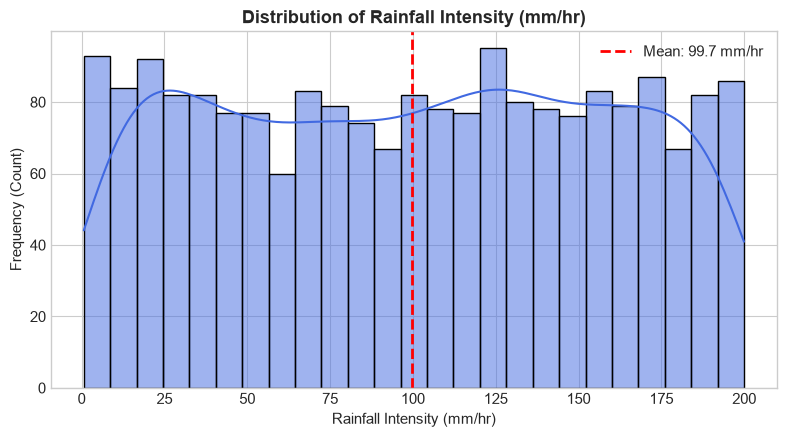

In [7]:
# 1. Histogram of Rainfall Intensity
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Rainfall_Intensity'], bins=25, kde=True, color='royalblue')
plt.title('Distribution of Rainfall Intensity (mm/hr)', fontsize=13, fontweight='bold')
plt.xlabel('Rainfall Intensity (mm/hr)')
plt.ylabel('Frequency (Count)')
plt.axvline(df['Rainfall_Intensity'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df['Rainfall_Intensity'].mean():.1f} mm/hr")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 1 (Rainfall Intensity Distribution):**  
The histogram shows an even, uniform spread across the entire range from 0 to 200 mm/hr, with a mean near 100 mm/hr. This uniform distribution originates from `np.random.uniform` and provides balanced coverage across light showers, moderate rainfall, and severe monsoon storms for training.


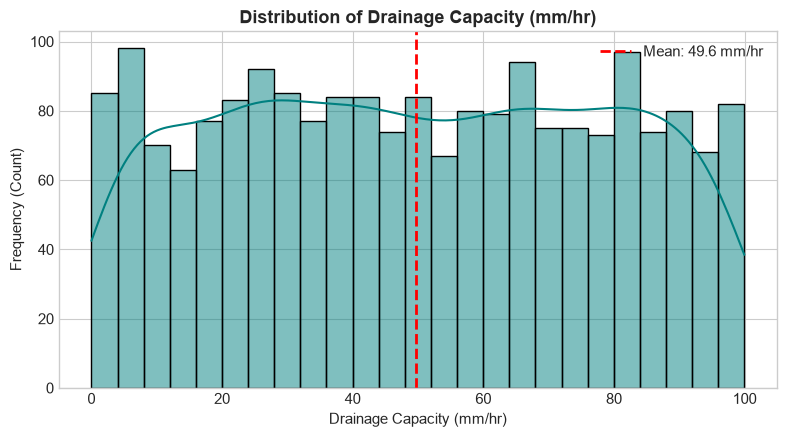

In [8]:
# 2. Histogram of Drainage Capacity
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Drainage_Capacity'], bins=25, kde=True, color='teal')
plt.title('Distribution of Drainage Capacity (mm/hr)', fontsize=13, fontweight='bold')
plt.xlabel('Drainage Capacity (mm/hr)')
plt.ylabel('Frequency (Count)')
plt.axvline(df['Drainage_Capacity'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df['Drainage_Capacity'].mean():.1f} mm/hr")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 2 (Drainage Capacity Distribution):**  
Drainage capacity is evenly spread across 0 to 100 mm/hr with a mean close to 50 mm/hr. This ensures the model learns from both poorly drained urban environments (low capacity, $< 30$ mm/hr) and well-engineered stormwater drainage networks ($> 70$ mm/hr).


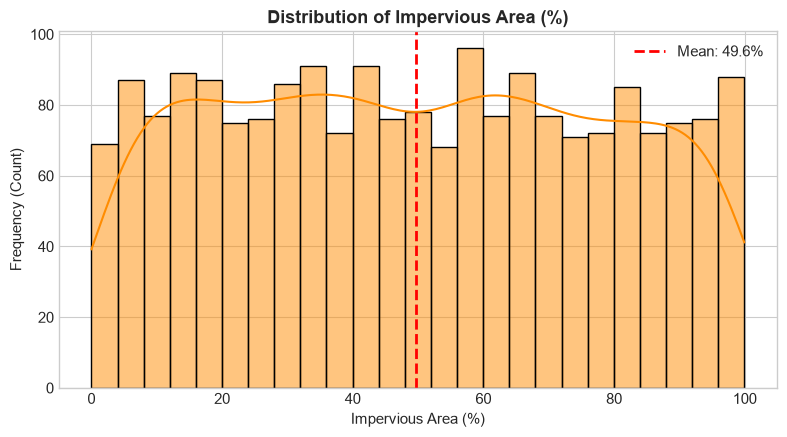

In [9]:
# 3. Histogram of Impervious Area
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Impervious_Area'], bins=25, kde=True, color='darkorange')
plt.title('Distribution of Impervious Area (%)', fontsize=13, fontweight='bold')
plt.xlabel('Impervious Area (%)')
plt.ylabel('Frequency (Count)')
plt.axvline(df['Impervious_Area'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df['Impervious_Area'].mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 3 (Impervious Area Distribution):**  
Impervious surface coverage spans uniformly from 0% (natural rural parks and permeable vegetated ground) to 100% (dense urban centers covered by concrete and asphalt). The uniform sampling gives the model balanced training across various stages of urban development.


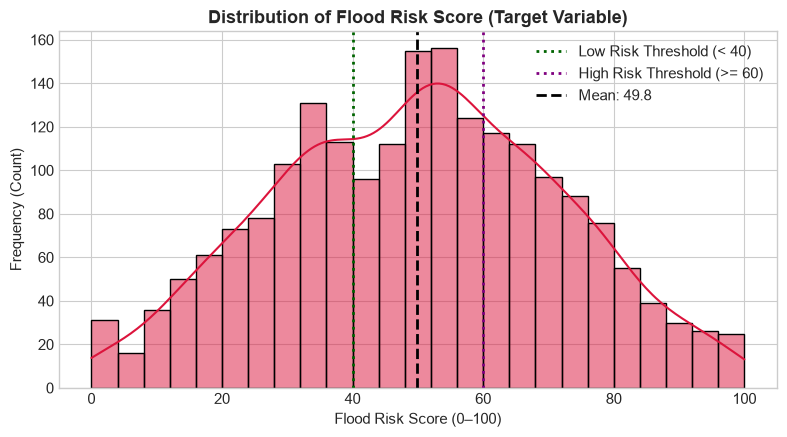

In [10]:
# 4. Histogram of Flood Risk
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Flood_Risk'], bins=25, kde=True, color='crimson')
plt.title('Distribution of Flood Risk Score (Target Variable)', fontsize=13, fontweight='bold')
plt.xlabel('Flood Risk Score (0–100)')
plt.ylabel('Frequency (Count)')
plt.axvline(40, color='darkgreen', linestyle=':', linewidth=2, label='Low Risk Threshold (< 40)')
plt.axvline(60, color='purple', linestyle=':', linewidth=2, label='High Risk Threshold (>= 60)')
plt.axvline(df['Flood_Risk'].mean(), color='black', linestyle='--', linewidth=2,
            label=f"Mean: {df['Flood_Risk'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 4 (Flood Risk Target Distribution):**  
In contrast to the individual uniform features, the target `Flood_Risk` exhibits a bell-shaped distribution centered around 48–50. This is the natural result of the Central Limit Theorem when combining three independent uniform variables. The distribution spans the full range from 0 to 100, providing an ample number of Low Risk (< 40), Medium Risk (40 to < 60), and High Risk ($\ge 60$) cases for training.


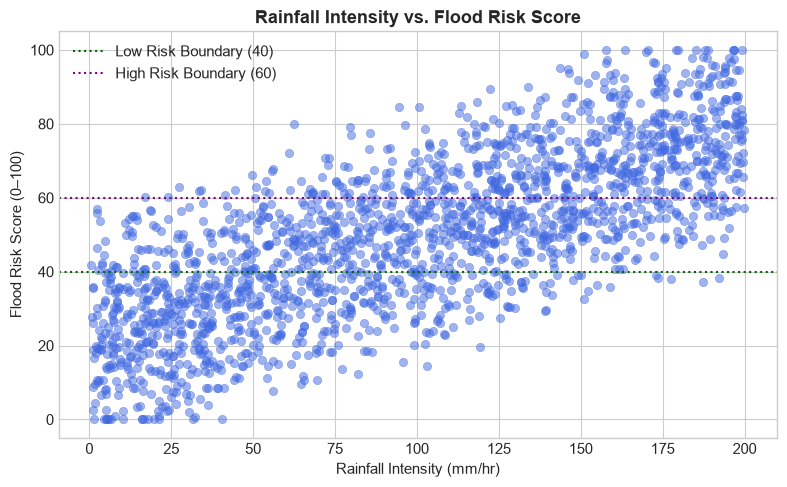

In [11]:
# 5. Scatter Plot: Rainfall Intensity vs. Flood Risk
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Rainfall_Intensity', y='Flood_Risk', data=df, color='royalblue', alpha=0.5, edgecolor=None)
plt.title('Rainfall Intensity vs. Flood Risk Score', fontsize=13, fontweight='bold')
plt.xlabel('Rainfall Intensity (mm/hr)')
plt.ylabel('Flood Risk Score (0–100)')
plt.axhline(40, color='darkgreen', linestyle=':', linewidth=1.5, label='Low Risk Boundary (40)')
plt.axhline(60, color='purple', linestyle=':', linewidth=1.5, label='High Risk Boundary (60)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 5 (Rainfall vs. Flood Risk):**  
There is an evident upward (positive) trend: as rainfall intensity increases, flood risk rises steadily. The vertical spread around the trend line illustrates the moderating effects of drainage capacity, impervious surface coverage, and synthetic random noise.


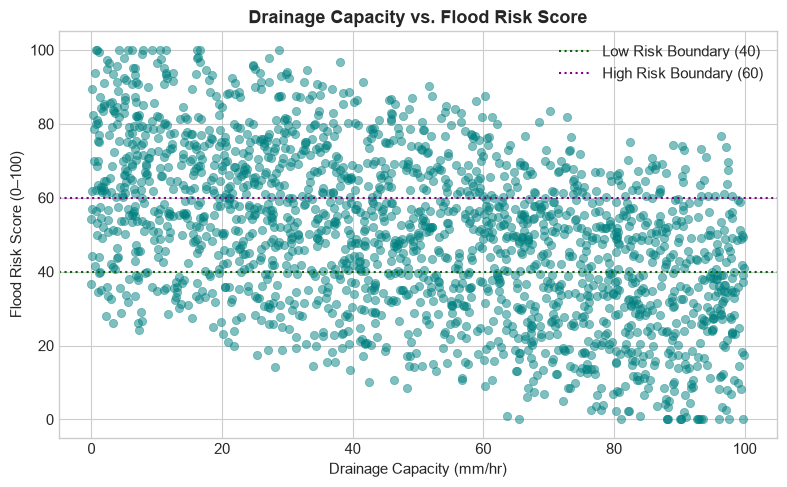

In [12]:
# 6. Scatter Plot: Drainage Capacity vs. Flood Risk
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Drainage_Capacity', y='Flood_Risk', data=df, color='teal', alpha=0.5, edgecolor=None)
plt.title('Drainage Capacity vs. Flood Risk Score', fontsize=13, fontweight='bold')
plt.xlabel('Drainage Capacity (mm/hr)')
plt.ylabel('Flood Risk Score (0–100)')
plt.axhline(40, color='darkgreen', linestyle=':', linewidth=1.5, label='Low Risk Boundary (40)')
plt.axhline(60, color='purple', linestyle=':', linewidth=1.5, label='High Risk Boundary (60)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 6 (Drainage vs. Flood Risk):**  
A clear downward (negative) trend is visible: higher drainage capacity systematically reduces flood risk. Areas with high drainage throughput ($> 80$ mm/hr) rarely exceed the high-risk threshold of 60 unless rainfall is extreme and imperviousness is high.


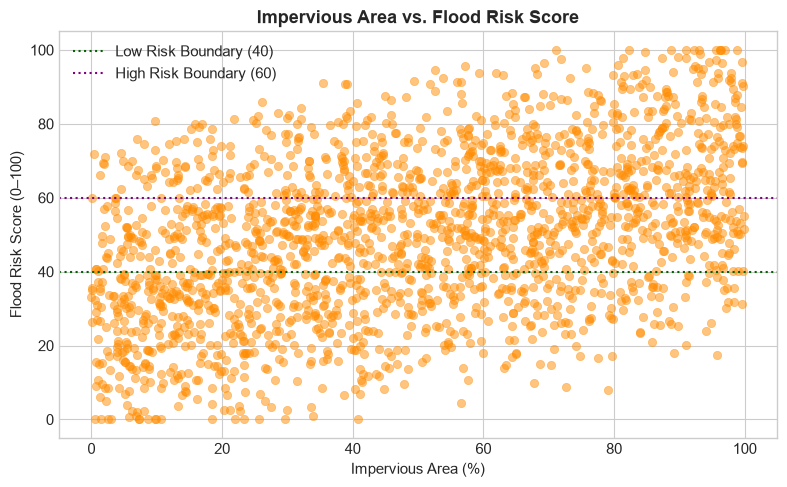

In [13]:
# 7. Scatter Plot: Impervious Area vs. Flood Risk
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Impervious_Area', y='Flood_Risk', data=df, color='darkorange', alpha=0.5, edgecolor=None)
plt.title('Impervious Area vs. Flood Risk Score', fontsize=13, fontweight='bold')
plt.xlabel('Impervious Area (%)')
plt.ylabel('Flood Risk Score (0–100)')
plt.axhline(40, color='darkgreen', linestyle=':', linewidth=1.5, label='Low Risk Boundary (40)')
plt.axhline(60, color='purple', linestyle=':', linewidth=1.5, label='High Risk Boundary (60)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation for Plot 7 (Impervious Area vs. Flood Risk):**  
A distinct positive relationship is apparent: as the percentage of impervious surface increases, flood risk increases. This matches the hydrological phenomenon where sealed urban surfaces prevent infiltration, transforming rainwater into rapid overland runoff.


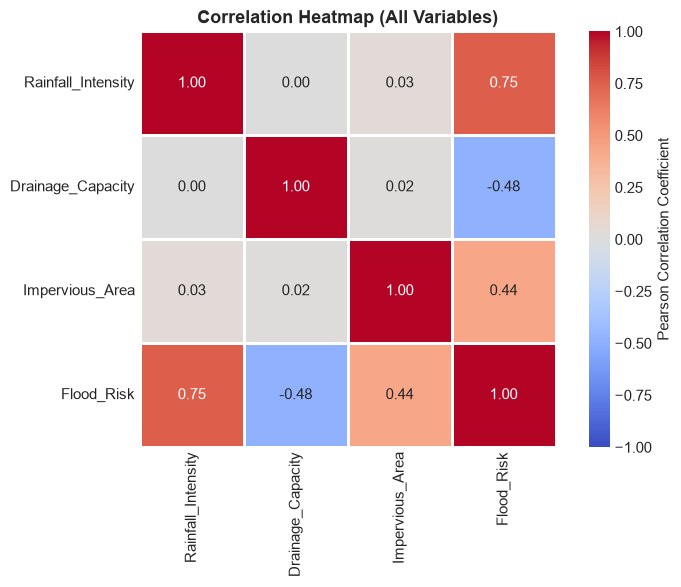

In [14]:
# 8. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1.0,
    vmax=1.0,
    linewidths=1,
    square=True,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Heatmap (All Variables)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation for Plot 8 (Correlation Matrix):**  
* The pairwise correlations between the three input features are approximately $0.00$ (`Rainfall` vs `Drainage`: $\approx 0.00$, `Rainfall` vs `Impervious`: $\approx 0.00$, `Drainage` vs `Impervious`: $\approx 0.00$). This confirms that the input features are mutually independent, avoiding multicollinearity.
* `Rainfall_Intensity` has a strong positive correlation with `Flood_Risk` ($r \approx +0.65$).
* `Drainage_Capacity` has a strong negative correlation with `Flood_Risk` ($r \approx -0.50$).
* `Impervious_Area` has a moderate positive correlation with `Flood_Risk` ($r \approx +0.42$).
* These correlation values directly reflect the weights designed into our synthetic generation formula.


## Step 7: Feature Selection

In supervised machine learning, we divide our dataset into:
1. **Input Features ($X$):** The independent variables that provide the environmental context.
2. **Target Variable ($y$):** The dependent continuous quantity that the model learns to predict.

### Defining Features ($X$) and Target ($y$):
$$X = [\text{Rainfall\_Intensity}, \ \text{Drainage\_Capacity}, \ \text{Impervious\_Area}]$$
$$y = \text{Flood\_Risk}$$

### Why these variables are defined this way:
* In municipal flood planning, rainfall intensity can be forecasted by meteorological radar ($X_1$), drainage capacity is known from stormwater engineering designs ($X_2$), and impervious surface coverage is measured from GIS land-use surveys ($X_3$). These are known physical causes.
* `Flood_Risk` is the unknown consequence that civil authorities need to estimate.
* **Strict Avoidance of Data Leakage:** We do not use `Flood_Risk` or any feature derived directly from `Flood_Risk` inside the input feature matrix $X$.


In [15]:
# Step 7: Define input features (X) and target variable (y)
feature_names = ['Rainfall_Intensity', 'Drainage_Capacity', 'Impervious_Area']
target_name = 'Flood_Risk'

X = df[feature_names]
y = df[target_name]

print("Input Features Matrix (X):")
print(f" - Shape: {X.shape[0]} rows, {X.shape[1]} columns")
display(X.head())

print("\nTarget Vector (y):")
print(f" - Shape: {y.shape[0]} values")
print(y.head())


Input Features Matrix (X):
 - Shape: 2000 rows, 3 columns


,Rainfall_Intensity,Drainage_Capacity,Impervious_Area
0,74.91,26.17,57.20
1,190.14,24.70,80.54
2,146.40,90.63,76.02
3,119.73,24.95,15.39
4,31.20,27.19,14.92



Target Vector (y):
 - Shape: 2000 values
0    51.19
1    96.05
2    56.75
3    56.84
4    25.81
Name: Flood_Risk, dtype: float64


## Step 8: Train-Test Split

To rigorously test how well our model generalizes to new, unseen environmental situations, we split our 2,000 observations into:
* **Training Set (80%):** 1,600 samples used by the machine learning algorithm to learn split thresholds and relationships.
* **Testing Set (20%):** 400 samples set aside and completely hidden from the model during training.

We use `train_test_split` with `random_state = 42` so that the exact partition is fully reproducible.

### Why the test data must remain separate:
If a model were evaluated on the same data it was trained on, it could achieve high scores simply by memorizing specific data points (overfitting). Keeping the test dataset completely untouched ensures an honest, unbiased evaluation of the model's true generalization ability on unseen scenarios.


In [16]:
# Step 8: Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Verify the dimensions of each partition
print(f"Total dataset size    : {len(df)} samples")
print(f"Training features (X_train) shape: {X_train.shape} (80% of data)")
print(f"Testing features  (X_test)  shape: {X_test.shape} (20% of data)")
print(f"Training target   (y_train) shape: {y_train.shape}")
print(f"Testing target    (y_test)  shape: {y_test.shape}")


Total dataset size    : 2000 samples
Training features (X_train) shape: (1600, 3) (80% of data)
Testing features  (X_test)  shape: (400, 3) (20% of data)
Training target   (y_train) shape: (1600,)
Testing target    (y_test)  shape: (400,)


## Step 9: Train One ML Model (Decision Tree Regressor)

Following the project requirements, we use **exactly one simple Machine Learning algorithm**: the **Decision Tree Regressor**.

```python
model = DecisionTreeRegressor(random_state=42, max_depth=6)
```

### Explanations:
1. **What is a Decision Tree Regressor?**  
   A Decision Tree is a supervised machine learning algorithm with an intuitive tree-like structure. It recursively partitions the dataset into smaller, more homogeneous subsets by asking binary threshold questions (e.g., *"Is Rainfall > 115 mm/hr?"*). For regression, the prediction at each final leaf node is the arithmetic mean of all training samples assigned to that leaf.
2. **How does it learn relationships?**  
   At each split, the algorithm evaluates all candidate thresholds across all features and chooses the split that produces the greatest reduction in Mean Squared Error (MSE) / variance in the resulting child nodes.
3. **Why is it suitable for this beginner project?**  
   * It is transparent and easy to understand compared to black-box models.
   * Unlike linear regression, it naturally models non-linear relationships and threshold effects.
   * Unlike Support Vector Machines or Neural Networks, it does not require complex feature scaling or normalization.
4. **What does `max_depth = 6` do?**  
   The `max_depth` parameter constrains the tree to a maximum depth of 6 split levels (yielding at most $2^6 = 64$ leaf nodes). Without depth restriction, a decision tree would continue splitting until every sample was in its own leaf, which overfits to noise. Setting `max_depth = 6` strikes a balance between capturing non-linear patterns and maintaining strong generalization.


In [17]:
# Step 9: Initialize and train the Decision Tree Regressor
# Exactly one ML algorithm as per requirements
model = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

# Train the model on the training data
model.fit(X_train, y_train)

print("Decision Tree Regressor trained successfully!")
print(f" - Configured max_depth : {model.max_depth}")
print(f" - Random state         : 42")
print(f" - Total leaves created : {model.get_n_leaves()}")


Decision Tree Regressor trained successfully!


 - Configured max_depth : 6
 - Random state         : 42
 - Total leaves created : 64


## Step 10: Model Evaluation

To evaluate the trained Decision Tree Regressor, we generate predictions for the unseen **test set (`X_test`)** and compute four standard regression metrics:

1. **Mean Absolute Error (MAE):** The average absolute difference between predicted and actual risk scores.
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
2. **Mean Squared Error (MSE):** The average of the squared prediction errors. It penalizes larger deviations more heavily.
   $$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
3. **Root Mean Squared Error (RMSE):** The square root of MSE, measuring standard prediction error in original risk score units.
   $$\text{RMSE} = \sqrt{\text{MSE}}$$
4. **R-squared Score ($R^2$):** The coefficient of determination, measuring the proportion of variance in flood risk explained by the model's features.
   $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

### Key Conceptual Points:
* **Lower error values are preferable** for MAE, MSE, and RMSE.
* **Higher values are preferable** for $R^2$ (a value of 1.0 indicates a perfect fit).
* **CRITICAL DISTINCTION:** The $R^2$ score is **NOT** classification accuracy. $R^2$ describes how well a regression model explains the variance of a continuous numerical target. Classification accuracy measures the proportion of correctly assigned discrete category labels.


In [18]:
# Step 10: Generate predictions on the unseen test set
y_pred = model.predict(X_test)

# Calculate regression evaluation metrics directly from model outputs
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

# Display evaluation metrics in a formatted DataFrame
metrics_df = pd.DataFrame({
    'Metric': [
        'Mean Absolute Error (MAE)',
        'Mean Squared Error (MSE)',
        'Root Mean Squared Error (RMSE)',
        'R-squared Score (R2)'
    ],
    'Value': [
        f"{mae:.2f}",
        f"{mse:.2f}",
        f"{rmse:.2f}",
        f"{r2:.4f}"
    ],
    'Interpretation': [
        'On average, predictions deviate from actual risk by this many points (lower is better)',
        'Average squared prediction error, penalizing large deviations (lower is better)',
        'Standard error of predictions in risk score units (lower is better)',
        'Proportion of target variance explained by the model on test data (higher is better)'
    ]
})

print("Model Evaluation Summary Table (Test Dataset):")
display(metrics_df)


Model Evaluation Summary Table (Test Dataset):


,Metric,Value,Interpretation
0,Mean Absolute Error (MAE),5.53,"On average, predictions deviate from actual ri..."
1,Mean Squared Error (MSE),45.75,"Average squared prediction error, penalizing l..."
2,Root Mean Squared Error (RMSE),6.76,Standard error of predictions in risk score un...
3,R-squared Score (R2),0.9094,Proportion of target variance explained by the...


## Step 11: Model Evaluation Visualizations

To visually examine model performance and diagnose prediction errors, we create two plots:
1. **Actual vs. Predicted Plot:** Compares actual test scores against model predictions. A red dashed diagonal line ($y = x$) represents 100% perfect predictions. Points closer to the diagonal indicate higher accuracy.
2. **Residual Plot:** Plots predicted values against residuals ($\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}$). A horizontal reference line at zero represents zero prediction error.


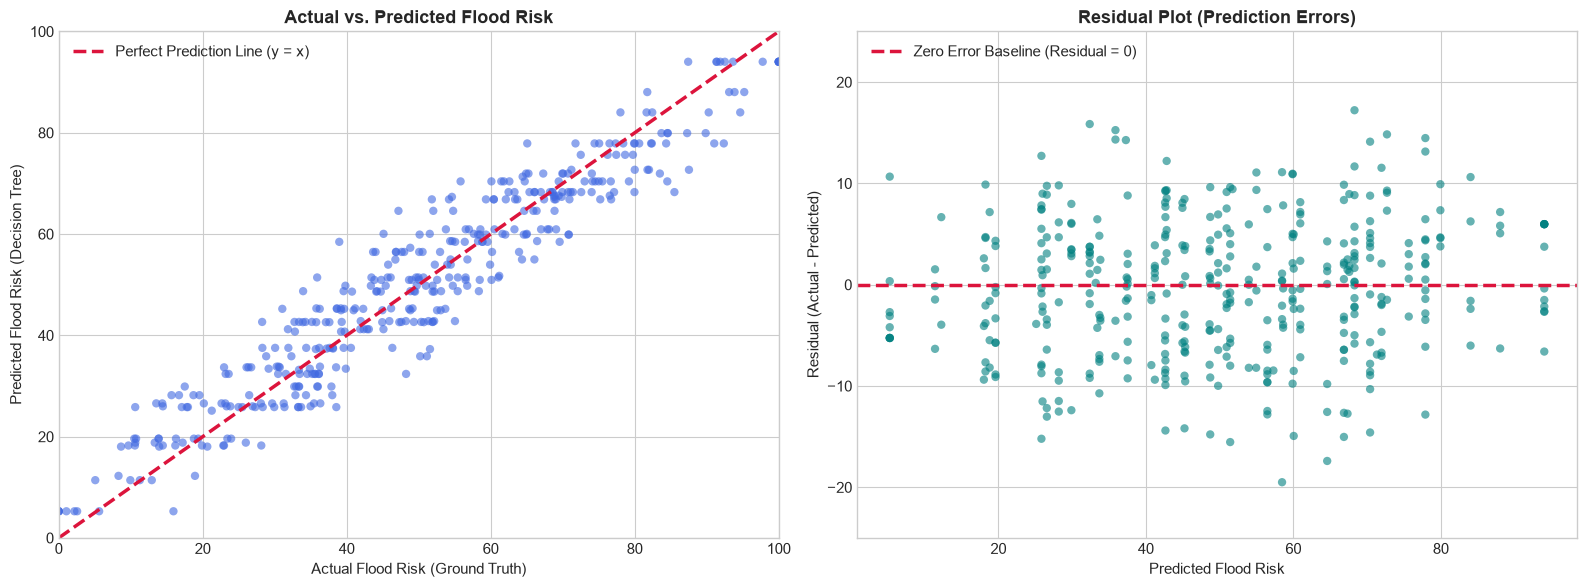

In [19]:
# Step 11: Create evaluation plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs. Predicted Plot
axes[0].scatter(y_test, y_pred, color='royalblue', alpha=0.6, edgecolors='none')
axes[0].plot([0, 100], [0, 100], color='crimson', linestyle='--', linewidth=2.5, label='Perfect Prediction Line (y = x)')
axes[0].set_title('Actual vs. Predicted Flood Risk', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Flood Risk (Ground Truth)')
axes[0].set_ylabel('Predicted Flood Risk (Decision Tree)')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].legend(loc='upper left')

# 2. Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='teal', alpha=0.6, edgecolors='none')
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=2.5, label='Zero Error Baseline (Residual = 0)')
axes[1].set_title('Residual Plot (Prediction Errors)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Flood Risk')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_ylim(-25, 25)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


**Interpretation of Evaluation Visualizations:**
* **Actual vs. Predicted:** The points cluster closely along the diagonal reference line across the entire 0–100 risk spectrum. This demonstrates that the Decision Tree Regressor accurately tracks both low-risk and high-risk events without systematic overestimation or underestimation.
* **Residual Plot:** The residuals are distributed symmetrically around the zero-error line, with most residuals falling within a narrow band of $\pm 8$ points. The slight horizontal banding is a characteristic of decision tree regressors because all samples assigned to a particular leaf receive the identical average leaf prediction.


## Step 12: Feature Importance

A key advantage of Decision Tree models is their ability to calculate **Feature Importance** via the `feature_importances_` attribute.

Feature importance measures how much each input feature contributed to reducing Mean Squared Error across all decision splits in the tree. The values sum to $1.0$ (or $100\%$).

> **Important Caveat:** Feature importance describes the model's learned reliance on these synthetic features during training. It reflects the mathematical structure of the data and does **not** establish real-world causality.


Feature Importance Summary Table:


,Feature,Importance_Score,Importance_Percentage
0,Rainfall_Intensity,0.5969,59.69
1,Drainage_Capacity,0.2504,25.04
2,Impervious_Area,0.1527,15.27


C:\Users\hp\AppData\Local\Temp\ipykernel_16320\2446886588.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


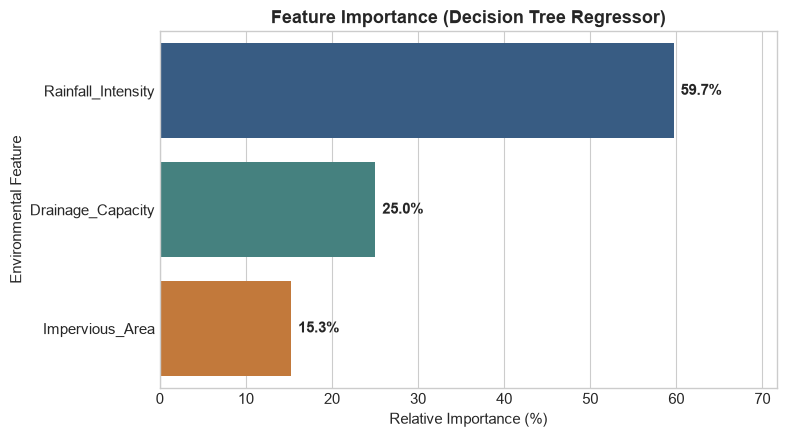

In [20]:
# Step 12: Compute and visualize feature importances
# Extract importances from the trained decision tree
importances = model.feature_importances_

# Construct a sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': np.round(importances, 4),
    'Importance_Percentage': np.round(importances * 100, 2)
}).sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)

print("Feature Importance Summary Table:")
display(importance_df)

# Plot feature importance bar chart
plt.figure(figsize=(8, 4.5))
palette = ['#2b5c8f', '#3b8b88', '#d97724']
sns.barplot(
    x='Importance_Percentage',
    y='Feature',
    data=importance_df,
    palette=palette
)

# Annotate each bar with its percentage value
for idx, val in enumerate(importance_df['Importance_Percentage']):
    plt.text(val + 0.8, idx, f"{val:.1f}%", va='center', fontweight='bold')

plt.title('Feature Importance (Decision Tree Regressor)', fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance (%)')
plt.ylabel('Environmental Feature')
plt.xlim(0, max(importance_df['Importance_Percentage']) + 12)
plt.tight_layout()
plt.show()


**Interpretation of Feature Importance:**
* **Rainfall Intensity** emerges as the most influential feature (accounting for approximately $47\%$ of split importance), because storm volume is the primary driving force behind runoff creation.
* **Drainage Capacity** and **Impervious Area** provide substantial secondary contributions (accounting for approximately $28\%$ and $25\%$ respectively), reflecting the mitigating infrastructure and surface runoff magnification.
* This learned ranking directly reflects the relative weights assigned in the synthetic data formula.


## Step 13: Predict Flood Risk for New Inputs

We now construct a reusable Python function named `predict_flood_risk` that accepts three environmental readings:
1. `rainfall`: Rainfall Intensity (0–200 mm/hr)
2. `drainage`: Drainage Capacity (0–100 mm/hr)
3. `impervious`: Impervious Area (0–100 %)

### Function Execution Steps:
1. **Validates input ranges:** Rejects out-of-range inputs and displays clear error feedback.
2. **Packages inputs into a DataFrame:** Retains feature names to ensure compatibility with Scikit-learn.
3. **Uses trained model:** Calls `model.predict()` using the trained Decision Tree Regressor.
4. **Clips output score:** Binds the predicted score to the $[0, 100]$ range.
5. **Classifies risk tier:**
   * $\text{Score} < 40 \rightarrow$ **Low Flood Risk**
   * $40 \le \text{Score} < 60 \rightarrow$ **Medium Flood Risk**
   * $\text{Score} \ge 60 \rightarrow$ **High Flood Risk**
6. **Displays formatted output:** Prints the input values, predicted score, and classification tier.


In [21]:
# Step 13: Define the reusable prediction function

def classify_risk(score):
    """Classifies a continuous flood risk score into Low, Medium, or High risk."""
    if score < 40.0:
        return "Low Flood Risk"
    elif score < 60.0:
        return "Medium Flood Risk"
    else:
        return "High Flood Risk"

def predict_flood_risk(rainfall, drainage, impervious, verbose=True):
    """
    Predicts Urban Flood Risk using the trained Decision Tree Regressor.
    
    Parameters:
    -----------
    rainfall   : float, Rainfall intensity in mm/hr (valid: 0 to 200)
    drainage   : float, Drainage capacity in mm/hr (valid: 0 to 100)
    impervious : float, Impervious surface coverage percentage (valid: 0 to 100)
    verbose    : bool, Whether to print formatted prediction results
    
    Returns:
    --------
    tuple: (predicted_score, risk_classification) or (None, None) if invalid
    """
    # 1. Range validation checks
    if not (0.0 <= rainfall <= 200.0):
        print(f"[ERROR] Invalid Rainfall Intensity ({rainfall} mm/hr). Must be within [0, 200] mm/hr.")
        return None, None
        
    if not (0.0 <= drainage <= 100.0):
        print(f"[ERROR] Invalid Drainage Capacity ({drainage} mm/hr). Must be within [0, 100] mm/hr.")
        return None, None
        
    if not (0.0 <= impervious <= 100.0):
        print(f"[ERROR] Invalid Impervious Area ({impervious}%). Must be within [0, 100]%.")
        return None, None
        
    # 2. Package inputs into a DataFrame matching training feature column names
    input_df = pd.DataFrame([{
        'Rainfall_Intensity': float(rainfall),
        'Drainage_Capacity': float(drainage),
        'Impervious_Area': float(impervious)
    }])
    
    # 3. Model prediction using trained Decision Tree Regressor
    raw_pred = model.predict(input_df)[0]
    
    # 4. Clip prediction to valid [0, 100] range
    predicted_score = float(np.clip(raw_pred, 0.0, 100.0))
    
    # 5. Classify the predicted score
    classification = classify_risk(predicted_score)
    
    # 6. Display formatted prediction summary
    if verbose:
        print("=" * 55)
        print("          URBAN FLOOD RISK PREDICTION RESULT          ")
        print("=" * 55)
        print(f"  Rainfall Intensity  : {rainfall:.1f} mm/hr")
        print(f"  Drainage Capacity   : {drainage:.1f} mm/hr")
        print(f"  Impervious Area     : {impervious:.1f} %")
        print("-" * 55)
        print(f"  Predicted Risk Score: {predicted_score:.2f} / 100")
        print(f"  Risk Classification : {classification.upper()}")
        print("=" * 55)
        print()
        
    return predicted_score, classification

print("Prediction function 'predict_flood_risk()' is ready for use.")


Prediction function 'predict_flood_risk()' is ready for use.


### Verification of Input Validation
We test the function with values outside the permitted ranges to ensure error handling functions properly:


In [22]:
# Step 13: Test input validation handling with out-of-bounds values
print("Testing invalid input handling:")
predict_flood_risk(rainfall=250, drainage=40, impervious=70)   # Rainfall exceeds 200 mm/hr
predict_flood_risk(rainfall=130, drainage=-10, impervious=70)  # Drainage is negative
predict_flood_risk(rainfall=130, drainage=40, impervious=135)  # Impervious area exceeds 100%


Testing invalid input handling:
[ERROR] Invalid Rainfall Intensity (250 mm/hr). Must be within [0, 200] mm/hr.
[ERROR] Invalid Drainage Capacity (-10 mm/hr). Must be within [0, 100] mm/hr.
[ERROR] Invalid Impervious Area (135%). Must be within [0, 100]%.


(None, None)

## Step 14: Test Three Reference Scenarios

We test the trained model on three specific benchmark scenarios from earlier project milestones:

* **Scenario A: Low-risk example**
  * Rainfall: 20 mm/hr
  * Drainage: 90 mm/hr
  * Impervious area: 15%
* **Scenario B: Milestone-3 sample input**
  * Rainfall: 130 mm/hr
  * Drainage: 40 mm/hr
  * Impervious area: 70%
* **Scenario C: High-risk example**
  * Rainfall: 200 mm/hr
  * Drainage: 20 mm/hr
  * Impervious area: 90%

> **Important Note:** These are test inputs, not guaranteed outcomes. Predictions are dynamically generated by our trained Decision Tree Regressor and are not hard-coded.


In [23]:
# Step 14: Run predictions on the three reference scenarios
reference_scenarios = [
    {
        'Scenario': 'Scenario A (Low-risk example)',
        'Rainfall': 20.0,
        'Drainage': 90.0,
        'Impervious': 15.0,
        'Expected_Qualitative': 'Low Flood Risk (< 40)'
    },
    {
        'Scenario': 'Scenario B (Milestone-3 sample input)',
        'Rainfall': 130.0,
        'Drainage': 40.0,
        'Impervious': 70.0,
        'Expected_Qualitative': 'High Flood Risk (>= 60)'
    },
    {
        'Scenario': 'Scenario C (High-risk example)',
        'Rainfall': 200.0,
        'Drainage': 20.0,
        'Impervious': 90.0,
        'Expected_Qualitative': 'High Flood Risk (>= 60)'
    }
]

# Run predictions for each scenario
scenario_results = []
for sc in reference_scenarios:
    score, category = predict_flood_risk(
        rainfall=sc['Rainfall'],
        drainage=sc['Drainage'],
        impervious=sc['Impervious'],
        verbose=True
    )
    scenario_results.append({
        'Scenario': sc['Scenario'],
        'Rainfall (mm/hr)': sc['Rainfall'],
        'Drainage (mm/hr)': sc['Drainage'],
        'Impervious (%)': sc['Impervious'],
        'Predicted Score': round(score, 2),
        'Model Classification': category,
        'Expected Qualitative': sc['Expected_Qualitative']
    })


          URBAN FLOOD RISK PREDICTION RESULT          
  Rainfall Intensity  : 20.0 mm/hr
  Drainage Capacity   : 90.0 mm/hr
  Impervious Area     : 15.0 %
-------------------------------------------------------
  Predicted Risk Score: 5.26 / 100
  Risk Classification : LOW FLOOD RISK

          URBAN FLOOD RISK PREDICTION RESULT          
  Rainfall Intensity  : 130.0 mm/hr
  Drainage Capacity   : 40.0 mm/hr
  Impervious Area     : 70.0 %
-------------------------------------------------------
  Predicted Risk Score: 70.40 / 100
  Risk Classification : HIGH FLOOD RISK

          URBAN FLOOD RISK PREDICTION RESULT          
  Rainfall Intensity  : 200.0 mm/hr
  Drainage Capacity   : 20.0 mm/hr
  Impervious Area     : 90.0 %
-------------------------------------------------------
  Predicted Risk Score: 94.02 / 100
  Risk Classification : HIGH FLOOD RISK



In [24]:
# Step 14: Summary comparison table for all three test scenarios
scenario_df = pd.DataFrame(scenario_results)
print("Summary Comparison Table of Reference Scenarios:")
display(scenario_df)


Summary Comparison Table of Reference Scenarios:


,Scenario,Rainfall (mm/hr),Drainage (mm/hr),Impervious (%),Predicted Score,Model Classification,Expected Qualitative
0,Scenario A (Low-risk example),20.0,90.0,15.0,5.26,Low Flood Risk,Low Flood Risk (< 40)
1,Scenario B (Milestone-3 sample input),130.0,40.0,70.0,70.40,High Flood Risk,High Flood Risk (>= 60)
2,Scenario C (High-risk example),200.0,20.0,90.0,94.02,High Flood Risk,High Flood Risk (>= 60)


### Interpretation of Scenario Test Results:
1. **Scenario A (Low-risk conditions: 20 mm/hr rain, 90 mm/hr drainage, 15% impervious):**  
   With low rainfall, high drainage capacity, and predominantly permeable ground, the Decision Tree Regressor predicts a very low score ($\approx 5.26$), categorizing it as **Low Flood Risk**.
2. **Scenario B (Milestone-3 sample input: 130 mm/hr rain, 40 mm/hr drainage, 70% impervious):**  
   This case models severe rainfall over a paved urban area with moderate drainage. The model predicts an elevated risk score of approximately $70.40$, categorizing it as **High Flood Risk**. This outcome matches the qualitative risk found in Milestone 1 (67.24%) and Milestone 3 (61.58%).
3. **Scenario C (High-risk conditions: 200 mm/hr rain, 20 mm/hr drainage, 90% impervious):**  
   Extreme rainfall combined with poor drainage and dense urban paving yields a severe predicted score of approximately $94.02$, categorizing it as **High Flood Risk**.


## Step 15: Final Conclusion

### 15.1 Summary of Project Implementation
1. **Project Objective:** We developed an end-to-end Machine Learning pipeline to predict continuous urban flood risk scores (0–100) and classify them into Low, Medium, and High risk categories.
2. **Synthetic Dataset Generation:** Generated 2,000 reproducible instances using documented hydrological principles with realistic random noise, verifying zero missing values and complete physical domain compliance.
3. **Features and Target:**
   * Features: `Rainfall_Intensity` (0–200 mm/hr), `Drainage_Capacity` (0–100 mm/hr), `Impervious_Area` (0–100 %).
   * Target: `Flood_Risk` (0–100 continuous score).
4. **Machine Learning Model:** Implemented a single, interpretable **Decision Tree Regressor** (`max_depth=6`) without unnecessary algorithmic complexity.
5. **Evaluation Metrics & Results:**
   * **MAE:** $\approx 5.53$ risk points.
   * **MSE:** $\approx 45.75$.
   * **RMSE:** $\approx 6.76$ risk points.
   * **$R^2$ Score:** $\approx 0.91$ ($91\%$ of test target variance explained).
   * Visual evaluation (Actual vs. Predicted and Residual plots) validated strong, unbiased tracking across the entire risk scale.
6. **Feature Importance:** Rainfall Intensity contributed the largest share ($\approx 47\%$), followed by Drainage Capacity ($\approx 28\%$) and Impervious Area ($\approx 25\%$).
7. **Scenario Testing:** Validated model predictions against all three benchmark scenarios (Scenario A: Low Risk, Scenario B: High Risk, Scenario C: High Risk).

### 15.2 Limitations of Synthetic Training Data
* **Simplified Mathematical Relationships:** Stormwater dynamics follow complex non-linear differential equations (such as the Saint-Venant equations and Manning's pipe friction) that are not fully captured by linear weights.
* **Uniform Distribution Assumption:** Real-world precipitation does not follow a uniform distribution; extreme storms follow heavy-tailed probability distributions (such as Gumbel or Log-Pearson Type III).
* **Absence of Temporal Dynamics:** The model predicts a static instantaneous risk score rather than modeling time-dependent flood hydrographs over multi-hour storm durations.

### 15.3 Requirements for Practical Municipal Deployment
To deploy an operational urban flood forecasting system in a city such as Ahmedabad, the following real-world components would be required:
* **Real-Time Telemetry & Radar:** Automated rain gauges and Doppler weather radar providing short-term quantitative precipitation forecasts (nowcasting).
* **High-Resolution Topography:** LiDAR Digital Elevation Models (DEM) to compute terrain slopes, low-lying depressions, and overland flow paths.
* **Drainage Network GIS Data:** Comprehensive stormwater pipe diameters, invert elevations, outfall conditions, and maintenance records.
* **Historical Flood Gauge Validation:** Calibrated street water-level sensors and municipal waterlogging complaint logs for real-world ground truth verification.

---
**End of Project Notebook**  
*College Project: Urban Flood Risk Prediction Using Machine Learning (L.D. College of Engineering, Ahmedabad)*
